---
## 🔀 Dask for scalable data processing in the Cloud

#### **🎯 Objectives**
1. Learn Dask fundamentals for parallelizing Python codes
2. Deploy a Dask cluster on the cloud and connect from your GeoLab notebook.

#### **⚙️ Introduction to Dask**

Dask is a flexible, open-source Python library for parallel and distributed computing, allowing you to scale up your Python code and data processing workflows to handle larger-than-memory datasets and leverage multiple cores Here are key dask features and concepts:

**Parallel and Distributed Computing**: Dask enables you to run your Python code in parallel, either on a single machine with multiple cores or across a cluster of machines, significantly speeding up computations on large datasets. 

**Scalability**: Dask can handle datasets that are too large to fit into memory, allowing you to process and analyze them efficiently. 

**Integration with PyData Ecosystem**: Dask integrates seamlessly with popular Python libraries like NumPy, Pandas, and scikit-learn, allowing you to leverage your existing knowledge and tools. 

**Task Scheduling**: Dask uses a dynamic task scheduler to manage and optimize the execution of your code, ensuring efficient resource utilization and minimal overhead. 

**Collections API**: Dask provides "collections" like Dask arrays (parallel NumPy arrays) and Dask DataFrames (parallel Pandas DataFrames), which extend the functionality of these libraries to larger-than-memory and distributed environments. 

**Ease of Use**: Dask is designed to be easy to learn and use, with a familiar API and minimal configuration required. 


#### **🔧 How Dask Works**

1. Define your computation:
You write your code using familiar Python libraries like NumPy and Pandas, potentially with Dask collections for larger datasets.

2. Dask creates a task graph (lazy evaluation):
Dask analyzes your code and creates a graph of tasks to be executed.

3. Task scheduling:
Dask's task scheduler determines the optimal order and location to execute these tasks, taking into account available resources and dependencies.

4. Execution:
Dask executes the tasks in parallel, either on a single machine or across a distributed cluster. Calculations are only done when you explicitly ask for the results.

5. Result aggregation:
Dask collects the results from the executed tasks and combines them to produce the final output.

#### **🖼️ DASK architecture**
***Scheduler ↔ Workers ↔ Client***
![DASK architecture diagram](https://user-images.githubusercontent.com/306380/129031260-ad9600b0-1942-40ad-99a7-694ea2d3a382.jpg)

---

### DASK workflow

***In the next part, we will make workflows with directed acyclical graphs (DAGs), which are a type of graph where nodes are linked by one-way connections that do not form any cycles. DAGs are used to illustrate dependencies and causal relationships. This will help you to understand the DASK workflow in more details***

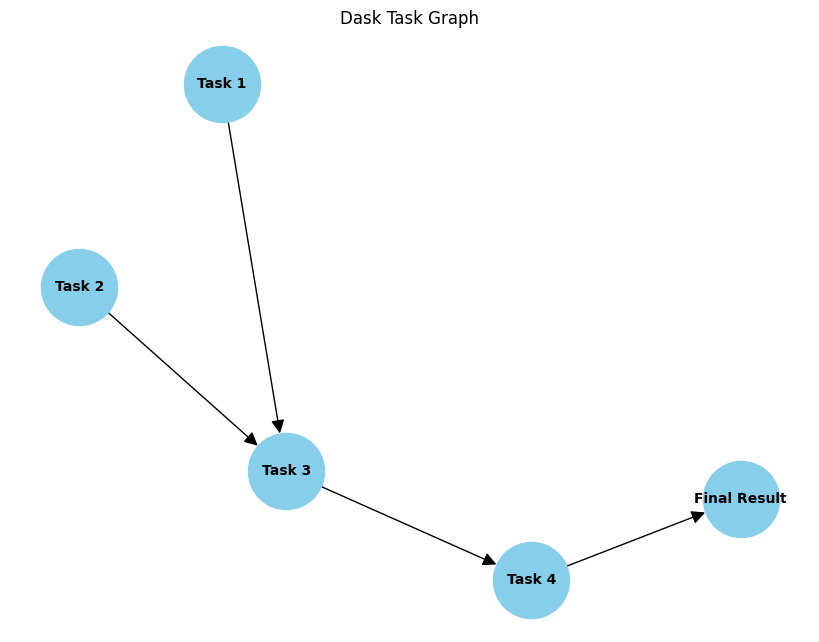

In [14]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes for tasks
G.add_node("Task 1")
G.add_node("Task 2")
G.add_node("Task 3")
G.add_node("Task 4")
G.add_node("Final Result")

# Add edges to show dependencies
G.add_edges_from([("Task 1", "Task 3"), ("Task 2", "Task 3"), ("Task 3", "Task 4"), ("Task 4", "Final Result")])

# Draw the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", font_size=10, font_weight="bold", arrowsize=20)

# Add title and labels
plt.title("Dask Task Graph")
plt.xlabel("Task Dependencies")
plt.ylabel("Execution Flow")

# Show the plot
plt.show()

#### Explanation of the DAG Diagram:

- Nodes (Tasks): Each circle represents a task. For example, "Task 1" and "Task 2" might be initial data processing steps.

- Edges (Dependencies): The arrows represent dependencies between tasks. For instance, "Task 3" depends on the completion of both "Task 1" and "Task 2".

- Parallel Execution: Tasks that do not depend on each other (like "Task 1" and "Task 2") are executed in parallel, speeding up the overall computation.

- Final Result: The final node represents the completion of all tasks and the production of the final result.

### ☁️ Deploy DASK on the cloud

***Now, we will run the same GNSS workflow you did in the previous notebook with Dask by following these steps:***

1. Dask client setup

    - Imports Dask’s APIs and spins up a local Client(), which you can monitor via the printed dashboard link.

2. Determine data bounds

    - Opens the TileDB array at uri, reads its non-empty time domain (ned), so you know the full time range of available SNR data.

3. Define a slicing function

    - slice_tiledb(path, slc) re-opens the same array and returns the SNR values for a given time‐slice slc.

4. Build a lazy Dask array

    - Chooses a chunk size (chunk = 43200000*4 milliseconds) and uses dask.delayed to create one delayed task per slice, marching through the array’s time domain.

    - Wraps all those delayed slices into a single dask.array via concatenate. At this point nothing has run yet.

5. Trigger the computation

    - Calls darray.persist() to start scheduling reads and then .mean().compute() to calculate the global mean SNR.

    - Measures how long this end-to-end process takes.

6. Report and visualize

    - Converts the domain endpoints back to human-readable dates and prints how many days of data were processed and in how many seconds.

    - Finally, draws a bar chart comparing how many days’ worth of GNSS data three different workflows can handle in roughly 30 s.

In [ ]:
import dask.dataframe as dd
from dask.distributed import Client


client = Client()
client

# Display the Dask dashboard link
print("Dask dashboard available at:", client.dashboard_link)

In [ ]:
# Get schema and Non-empty domain of Tdb object:
with tiledb.open(uri,mode="r", config=tdb_config,) as A:
    ned=A.nonempty_domain()
    # print(A.schema)

print(start)
start_t = time.time()
# This produces an array slice
def slice_tiledb(path, slc):
    with tiledb.open(uri,mode="r", config=tdb_config,) as A:
        return A[slc,0,:,12611]['snr']
        # return A[slc,:]['snr']
       

# Partition the array into delayed slices
chunk = 43200000*4 # tile size?
delayed_slices = list(
    dask.delayed(slice_tiledb)(uri, slice(int(start), int(start+chunk))) for 
                               start in 
                               np.arange(ned[0][0],ned[0][1]-chunk,step=chunk)) #-86400*1e3

# This creates a Dask array from the delayed slices
darray = dask.array.concatenate(
    dask.array.from_delayed(x,
                            shape=(chunk,), dtype=np.float64)
                            for x in delayed_slices)

#Everything up until here is lazy - nothing is really computed

# This triggers the entire computation
# print(darray.compute_chunk_sizes())
darray.persist()
gw_cluster = darray.mean().compute()

end_t = time.time()
gw_cluster_t=end_t - start_t

print('Object start date: ',utc_time(ned[0][0]))
print('Object end date: ',utc_time(ned[0][1]))

days_p=(ned[0][1]-ned[0][0])/(86400e3)
print('Processing %.01f days took %.01f seconds' %(days_p,gw_cluster_t))

fig, ax = plt.subplots(figsize=(8,4))
plt.bar(["Download and process: in GeoLab",
        "S3 and process: in GeoLab","Dask-Gateway in GeoLab"],
        [9,50,440])
plt.title("Amount of Days of GNSS Data Processed in about 30 seconds")
plt.xticks(rotation=90)
plt.show()